In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas_datareader as data
from twelvedata import TDClient
import pandas as pd
from dotenv import load_dotenv
import os

In [67]:
from datetime import date

# Load API key
load_dotenv()

api_key = os.getenv("TWELVEDATA_API_KEY")

td = TDClient(apikey=api_key)

START = "2000-01-01"
TODAY = date.today().strftime("%Y-%m-%d")

# Function to load stock data
def load_data(ticker):

    try:

        ts = td.time_series(
            symbol=ticker,

            # Best interval for maximum history
            interval="1day",

            start_date=START,
            end_date=TODAY,

            # Maximum rows allowed
            outputsize=5000
        )

        data = ts.as_pandas()

        # Check empty dataframe
        if data.empty:

            print(f"{ticker} is not supported in free tier.")

            return None

        # Reset index
        data.reset_index(inplace=True)

        # Rename columns
        data.rename(columns={
            'datetime': 'Date',
            'open': 'Open',
            'high': 'High',
            'low': 'Low',
            'close': 'Close',
            'volume': 'Volume'
        }, inplace=True)

        # Convert numeric columns
        numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

        for col in numeric_cols:
            if col in data.columns:
                data[col] = pd.to_numeric(
                    data[col],
                    errors='coerce'
                )

        # Convert date column
        data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

        # Sort by date
        data = data.sort_values(by='Date', ascending=True)
        
        # Reset index after sorting
        data.reset_index(drop=True, inplace=True)
        print(f"Loaded {len(data)} rows for {ticker}")

        return data

    except Exception as e:

        error_message = str(e)

        if "Grow or Venture plan" in error_message:

            print(f"{ticker} is not supported in free tier.")

        else:

            print(f"Error loading data for {ticker}:")
            print(error_message)

        return None

In [80]:
data = load_data('AAPL')
df=data
df.head()

Loaded 5000 rows for AAPL


,Date,Open,High,Low,Close,Volume
0,2006-07-06,2.03893,2.05000,1.98607,1.99179,633208800
1,2006-07-07,1.98143,2.01964,1.95250,1.97857,799360800
2,2006-07-10,1.98929,2.01750,1.94643,1.96429,529345600
3,2006-07-11,1.96821,1.99964,1.94750,1.98750,825022800
4,2006-07-12,1.97036,1.97286,1.89000,1.89143,927329200


In [81]:
df = df.drop(['Date'], axis = 1) # axis = 1 means column, axis = 0 means row
df.head()

,Open,High,Low,Close,Volume
0,2.03893,2.05000,1.98607,1.99179,633208800
1,1.98143,2.01964,1.95250,1.97857,799360800
2,1.98929,2.01750,1.94643,1.96429,529345600
3,1.96821,1.99964,1.94750,1.98750,825022800
4,1.97036,1.97286,1.89000,1.89143,927329200


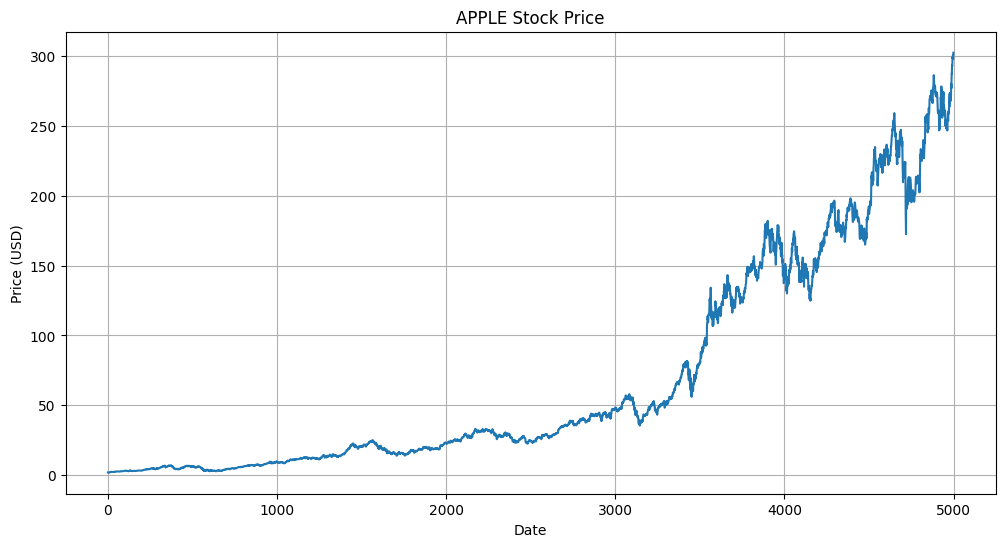

In [87]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'])
plt.title("APPLE Stock Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()

In [88]:
df

,Open,High,Low,Close,Volume
0,2.03893,2.05000,1.98607,1.99179,633208800
1,1.98143,2.01964,1.95250,1.97857,799360800
2,1.98929,2.01750,1.94643,1.96429,529345600
3,1.96821,1.99964,1.94750,1.98750,825022800
4,1.97036,1.97286,1.89000,1.89143,927329200
...,...,...,...,...,...
4995,299.82001,300.45001,295.38000,298.20999,35324900
4996,297.89999,303.20001,296.51999,300.23001,54862800
4997,300.23999,300.66000,294.91000,297.84000,34483000
4998,296.97000,300.51001,296.35001,298.97000,42243600



Plotting moving averages of 100 days

In [89]:
ma100 = df.Close.rolling(100).mean()
ma100

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
4995    265.107999
4996    265.373599
4997    265.642299
4998    265.908399
4999    266.192799
Name: Close, Length: 5000, dtype: float64

Text(0.5, 1.0, 'Graph Of Moving Averages Of 100 Days')

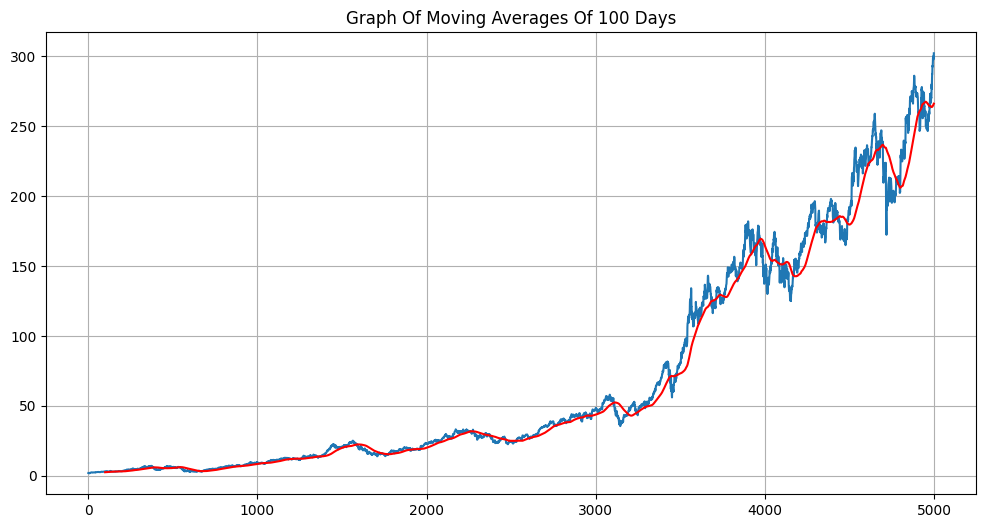

In [93]:
plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r') # 'r' means red color for the moving average line
plt.grid(True)
plt.title('Graph Of Moving Averages Of 100 Days')


Defining 200 days moving averages and plotting comparision graph with 100 days moving averages

In [94]:
ma200 = df.Close.rolling(200).mean()
ma200

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
4995    258.676549
4996    259.132449
4997    259.583799
4998    260.066749
4999    260.561249
Name: Close, Length: 5000, dtype: float64

Text(0.5, 1.0, 'Graph Of Moving Averages Of 200 Days')

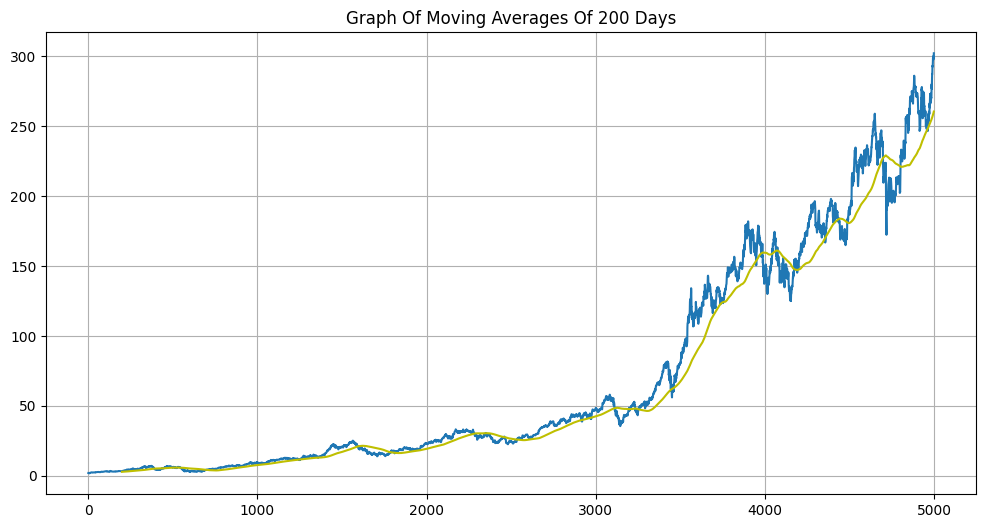

In [95]:
plt.figure(figsize = (12,6))
plt.plot(df['Close'])
plt.plot(ma200, 'y') # 'y' means yellow color for the moving average line
plt.grid(True)
plt.title('Graph Of Moving Averages Of 200 Days')

Text(0.5, 1.0, 'Comparison of Closing Price with 100-day and 200-day Moving Averages')

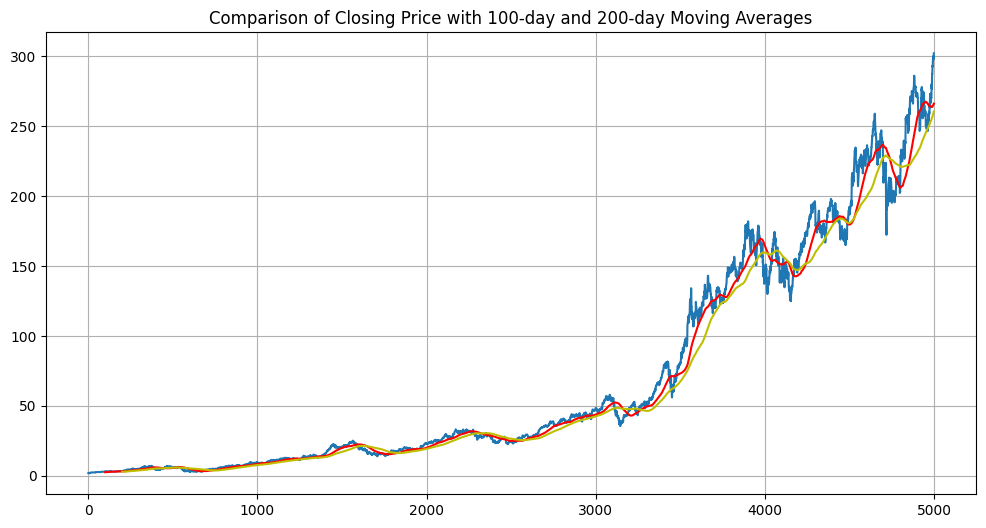

In [99]:
plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r') # 'r' means red color for the moving average line
plt.plot(ma200, 'y') # 'y' means yellow color for the moving average line
plt.grid(True)
plt.title('Comparison of Closing Price with 100-day and 200-day Moving Averages')

In [100]:
df.shape

(5000, 5)

Splitting the dataset into Training(70%), Validation(15%) and Testing(15%) set

In [101]:
total_data = len(data)

train_size = int(total_data * 0.70)

validation_size = int(total_data * 0.15)

# Remaining 15% automatically becomes test set
test_size = total_data - train_size - validation_size

# Train Dataset
train = pd.DataFrame(data[0:train_size])

# Validation Dataset
validation = pd.DataFrame(
    data[train_size:train_size + validation_size]
)

# Test Dataset
test = pd.DataFrame(
    data[train_size + validation_size:]
)

# Print Shapes
print("Train Shape:", train.shape)

print("Validation Shape:", validation.shape)

print("Test Shape:", test.shape)

Train Shape: (3500, 6)
Validation Shape: (750, 6)
Test Shape: (750, 6)


In [106]:
train.head()

,Date,Open,High,Low,Close,Volume
0,2006-07-06,2.03893,2.05000,1.98607,1.99179,633208800
1,2006-07-07,1.98143,2.01964,1.95250,1.97857,799360800
2,2006-07-10,1.98929,2.01750,1.94643,1.96429,529345600
3,2006-07-11,1.96821,1.99964,1.94750,1.98750,825022800
4,2006-07-12,1.97036,1.97286,1.89000,1.89143,927329200


In [103]:
validation.head()

,Date,Open,High,Low,Close,Volume
3500,2020-06-02,80.1875,80.8600,79.7325,80.835,87642800
3501,2020-06-03,81.1650,81.5500,80.5750,81.280,104491200
3502,2020-06-04,81.0975,81.4050,80.1950,80.580,87560400
3503,2020-06-05,80.8375,82.9375,80.8075,82.875,137250400
3504,2020-06-08,82.5625,83.4000,81.8300,83.365,95654400


In [104]:
test.head()

,Date,Open,High,Low,Close,Volume
4250,2023-05-24,171.09000,172.42000,170.52000,171.84000,45143500
4251,2023-05-25,172.41000,173.89999,171.69000,172.99001,56058300
4252,2023-05-26,173.32001,175.77000,173.11000,175.42999,54835000
4253,2023-05-30,176.96001,178.99001,176.57001,177.30000,55964400
4254,2023-05-31,177.33000,179.35001,176.75999,177.25000,99625300


Using MinMax scaler for normalization of the dataset

In [112]:
# -----------------------------------
# MinMax Scaling
# -----------------------------------

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

# Extract Close Prices
train_close = train[['Close']].values

validation_close = validation[['Close']].values

test_close = test[['Close']].values

# Fit scaler ONLY on training data
data_training_array = scaler.fit_transform(train_close)

# Transform validation and test data
data_validation_array = scaler.transform(validation_close)

data_testing_array = scaler.transform(test_close)

Create Training Sequences

In [113]:
x_train = []
y_train = []

for i in range(100,data_training_array.shape[0]):

    x_train.append(data_training_array[i-100:i])

    y_train.append(data_training_array[i, 0])

x_train = np.array(x_train)

y_train = np.array(y_train)

print("x_train shape:", x_train.shape)

print("y_train shape:", y_train.shape)

x_train shape: (3400, 100, 1)
y_train shape: (3400,)


Create Validation Sequences

In [114]:
x_val = []
y_val = []

for i in range(100,data_validation_array.shape[0]):

    x_val.append(data_validation_array[i-100:i])

    y_val.append(data_validation_array[i, 0])

x_val = np.array(x_val)

y_val = np.array(y_val)

print("x_val shape:", x_val.shape)

print("y_val shape:", y_val.shape)

x_val shape: (650, 100, 1)
y_val shape: (650,)


Create Testing Sequences

In [115]:
x_test = []
y_test = []

for i in range(100,data_testing_array.shape[0]):

    x_test.append(data_testing_array[i-100:i])

    y_test.append(data_testing_array[i, 0])

x_test = np.array(x_test)

y_test = np.array(y_test)

print("x_test shape:", x_test.shape)

print("y_test shape:", y_test.shape)

x_test shape: (650, 100, 1)
y_test shape: (650,)


Build LSTM Model

In [141]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

# First LSTM Layer
model.add(
    LSTM(
        units=50,

        activation='tanh',

        input_shape=(
            x_train.shape[1],
            1
        )
    )
)

model.add(
    Dropout(0.2)
)

# Output Layer
model.add(
    Dense(1)
)

# Compile Model
model.compile(
    optimizer='adam',

    loss='mean_squared_error',

    metrics=['mean_absolute_error']
)

model.summary()

e:\virtual\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [142]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [143]:
import tensorflow as tf

# -----------------------------------
# Compile Model
# -----------------------------------

model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=[tf.keras.metrics.MeanAbsoluteError()]
)

# -----------------------------------
# Train Model
# -----------------------------------

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),epochs=42,batch_size=32,verbose=1
)


Epoch 1/42
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0229 - mean_absolute_error: 0.0934 - val_loss: 0.0123 - val_mean_absolute_error: 0.0884
Epoch 2/42
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0014 - mean_absolute_error: 0.0238 - val_loss: 0.0167 - val_mean_absolute_error: 0.1079
Epoch 3/42
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0012 - mean_absolute_error: 0.0222 - val_loss: 0.0097 - val_mean_absolute_error: 0.0798
Epoch 4/42
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9.2516e-04 - mean_absolute_error: 0.0198 - val_loss: 0.0138 - val_mean_absolute_error: 0.0993
Epoch 5/42
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 9.6819e-04 - mean_absolute_error: 0.0200 - val_loss: 0.0117 - val_mean_absolute_error: 0.0922
Epoch 6/42
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 8.5694e-04 - mean_absolute_error: 0.0190 - val_loss: 0.0202 - val_mean_absolute_error: 0.1285
Epoch 7/42
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 8.6988e-04 - mean_abs

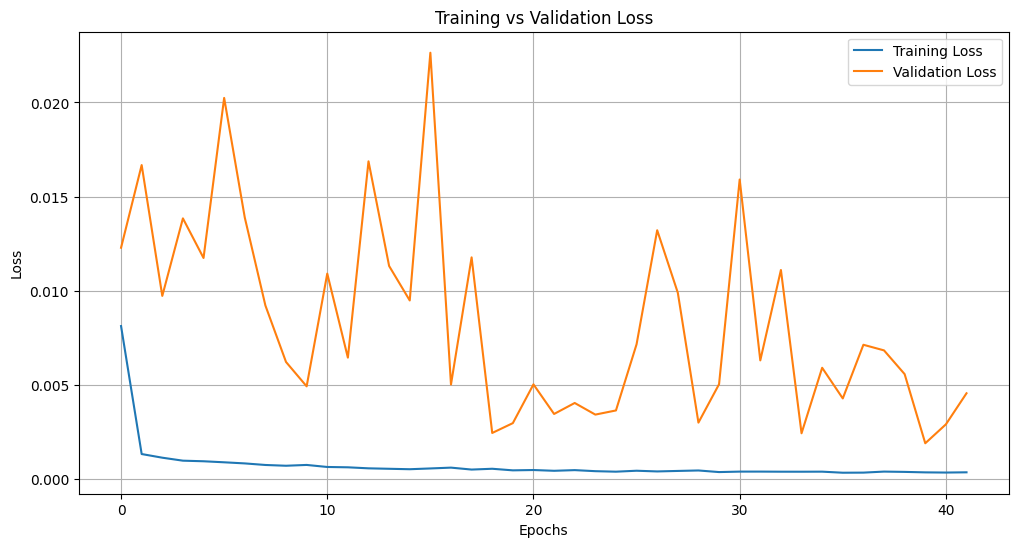

In [144]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

In [145]:
model.save('keras_model.h5')

In [146]:
test_close.shape

(750, 1)

In [147]:
past_100_days = pd.DataFrame(train_close[-100:])

In [148]:
test_df = pd.DataFrame(test_close)
test_df.head()

,0
0,171.84000
1,172.99001
2,175.42999
3,177.30000
4,177.25000


In [129]:
final_df = pd.concat([past_100_days, test_df],ignore_index=True)

In [149]:
final_df.head()

,0
0,75.7975
1,77.4075
2,77.5825
3,79.2400
4,78.1700


In [150]:
input_data = scaler.transform(final_df)

print(input_data.shape)

(850, 1)


Testing The Model

In [151]:
x_test = []
y_test = []
for i in range(100, input_data.shape[0]):
   x_test.append(input_data[i-100: i])
   y_test.append(input_data[i, 0])
x_test, y_test = np.array(x_test), np.array(y_test)
print(x_test.shape)
print(y_test.shape)

(750, 100, 1)
(750,)


In [152]:
# -----------------------------------
# Make Predictions
# -----------------------------------

y_pred = model.predict(x_test)

print("Prediction Shape:", y_pred.shape)



24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Prediction Shape: (750, 1)


In [137]:
# -----------------------------------
# Convert Back to Original Prices
# -----------------------------------

y_pred = scaler.inverse_transform(y_pred)

y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

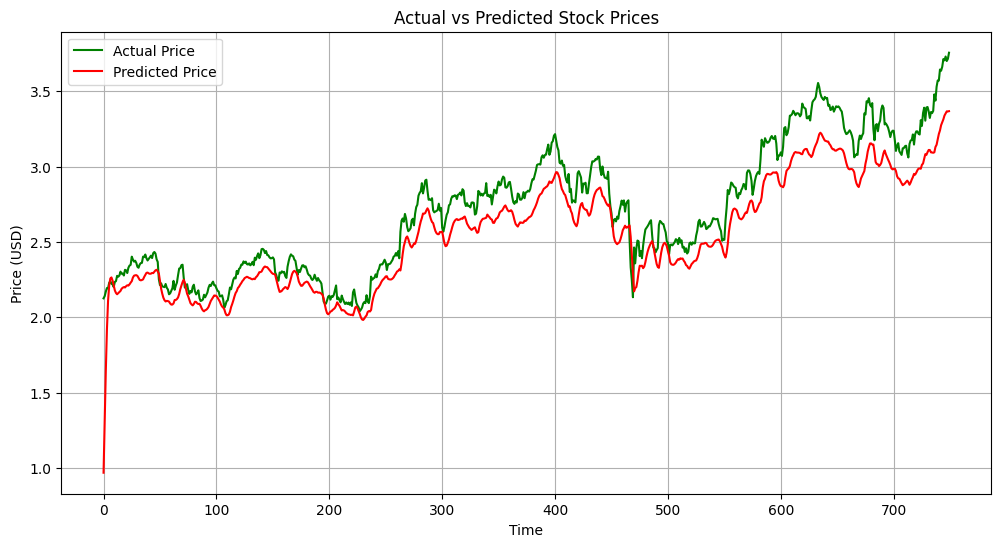

In [153]:
# -----------------------------------
# Plot Actual vs Predicted
# -----------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test,'g',label='Actual Price')

plt.plot(y_pred,'r',label='Predicted Price')

plt.xlabel("Time")

plt.ylabel("Price (USD)")

plt.title("Actual vs Predicted Stock Prices")

plt.legend()

plt.grid(True)

plt.show()